# 구간 합 구하기 5
## 실버 I
## 문제 
N×N개의 수가 N×N 크기의 표에 채워져 있다. $(x_1, y_1)$부터 $(x_2, y_2)$까지 합을 구하는 프로그램을 작성하시오. (x, y)는 x행 y열을 의미한다.

예를 들어, N = 4이고, 표가 아래와 같이 채워져 있는 경우를 살펴보자.

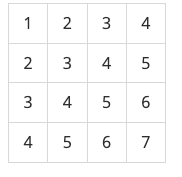

여기서 (2, 2)부터 (3, 4)까지 합을 구하면 3+4+5+4+5+6 = 27이고, (4, 4)부터 (4, 4)까지 합을 구하면 7이다.

표에 채워져 있는 수와 합을 구하는 연산이 주어졌을 때, 이를 처리하는 프로그램을 작성하시오.

## 입력
첫째 줄에 표의 크기 N과 합을 구해야 하는 횟수 M이 주어진다. (1 ≤ N ≤ 1024, 1 ≤ M ≤ 100,000) 둘째 줄부터 N개의 줄에는 표에 채워져 있는 수가 1행부터 차례대로 주어진다. 다음 M개의 줄에는 네 개의 정수 x1, y1, x2, y2 가 주어지며, (x1, y1)부터 (x2, y2)의 합을 구해 출력해야 한다. 표에 채워져 있는 수는 1,000보다 작거나 같은 자연수이다. (x1 ≤ x2, y1 ≤ y2)

## 출력
총 M줄에 걸쳐 (x1, y1)부터 (x2, y2)까지 합을 구해 출력한다.

In [ ]:
N, M = map(int, input().split()) # 표의 크기 -> N x N , M = 합을 구해야 하는 횟수

arr = [list(map(int, input().split())) for _ in range(N)]

# 이차원 배열 구간합(prefix sum)
# 1. 크기를 (N+1) x (N+1)로 만들기
prefix = [[0] * (N+1) for _ in range(N+1)]

for r in range(1, N+1):
    for c in range(1, N+1):
        prefix[r][c] = (
            arr[r-1][c-1]
            + prefix[r-1][c]
            + prefix[r][c-1]
            - prefix[r-1][c-1]
        )
print(prefix)

# 2. (x1, y1) ~ (x2, y2) 를 받아 구간합 구하기 
for _ in range(M):
    x1, y1, x2, y2 = map(int, input().split())

    result = (
        prefix[x2][y2]
        - prefix[x1-1][y2]
        - prefix [x2][y1-1]
        + prefix [x1-1][y1-1]
    )
    print(result)

### 📖 NOTE
- 질의마다 $O(N^2)$ 할 경우 시간초과 발생
    - 따라서 누적합으로 O(1)에 처리해야함
    - **2차원 누적합 배열 만들기** 
        - $S[r][c]=A[r][c]+S[r−1][c]+S[r][c−1]−S[r−1][c−1]$
    - **구간합 구하기**
        - $result=S[x2][y2]−S[x1−1][y2]−S[x2][y1−1]+S[x1−1][y1−1]$
            - $S[x1−1][y2]$ : 우리가 원하는 영역보다 위쪽을 뺌.
            - $S[x2][y1-1]$ : 왼쪽 부분을 뺌.